In [21]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

In [22]:
df = pd.read_csv("diabetic_data.csv", na_values="?", low_memory=False)

In [23]:
print("Business Understanding")
print("-"*40)
print("Objective:")
print("Analyze diabetes patient records to identify patient characteristics and factors affecting hospital readmission.")

Business Understanding
----------------------------------------
Objective:
Analyze diabetes patient records to identify patient characteristics and factors affecting hospital readmission.


In [24]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [25]:
df.tail()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
101761,443847548,100162476,AfricanAmerican,Male,[70-80),NaN,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),NaN,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),NaN,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),NaN,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO
101765,443867222,175429310,Caucasian,Male,[70-80),NaN,1,1,7,6,...,No,No,No,No,No,No,No,No,No,NO


In [26]:
print(df.shape)

(101766, 50)


In [27]:
print(df.columns)

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [29]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [30]:
df.isnull().sum()

,0
encounter_id,0
patient_nbr,0
race,2273
gender,0
age,0
weight,98569
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [31]:
df.duplicated().sum()

np.int64(0)

In [32]:
df.drop(
    columns=[
        "weight",
        "payer_code",
        "medical_specialty",
        "max_glu_serum",
        "A1Cresult"
    ],
    inplace=True
)

In [33]:
df["race"] = df["race"].fillna(df["race"].mode()[0])

df["diag_1"] = df["diag_1"].fillna(df["diag_1"].mode()[0])

df["diag_2"] = df["diag_2"].fillna(df["diag_2"].mode()[0])

df["diag_3"] = df["diag_3"].fillna(df["diag_3"].mode()[0])

In [34]:
df.isnull().sum()

,0
encounter_id,0
patient_nbr,0
race,0
gender,0
age,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0
num_lab_procedures,0


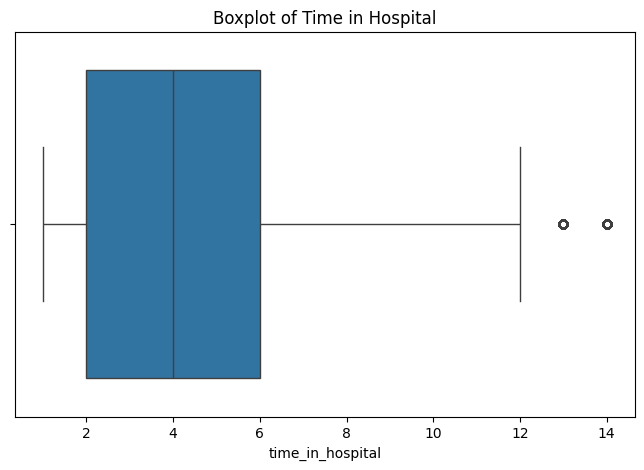

In [35]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["time_in_hospital"]
)

plt.title("Boxplot of Time in Hospital")

plt.show()

In [36]:
scaler = MinMaxScaler()

df["time_in_hospital"] = scaler.fit_transform(
    df[["time_in_hospital"]]
)

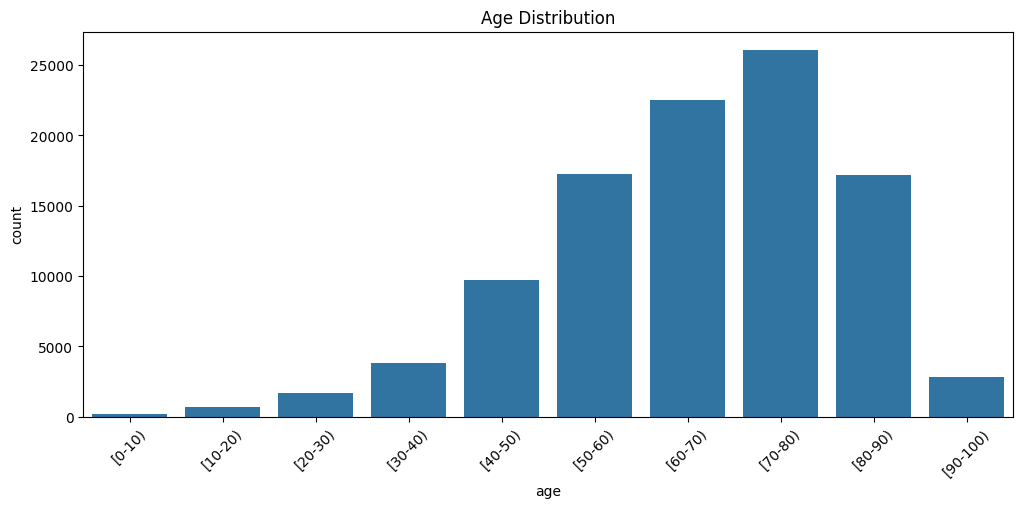

In [37]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x="age"
)

plt.title("Age Distribution")

plt.xticks(rotation=45)

plt.show()

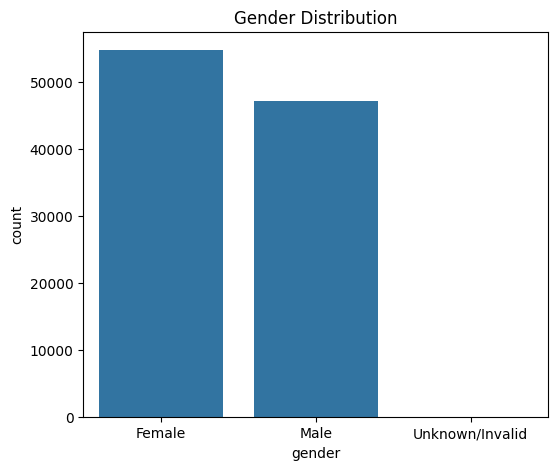

In [38]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="gender"
)

plt.title("Gender Distribution")

plt.show()

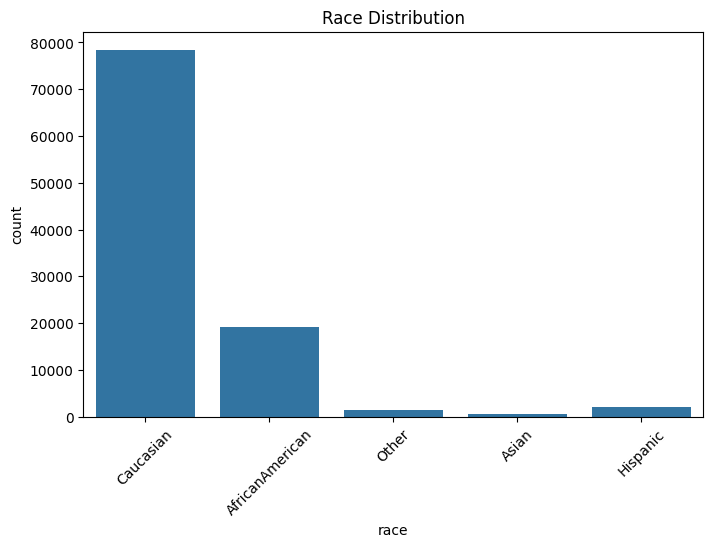

In [39]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="race"
)

plt.title("Race Distribution")

plt.xticks(rotation=45)

plt.show()

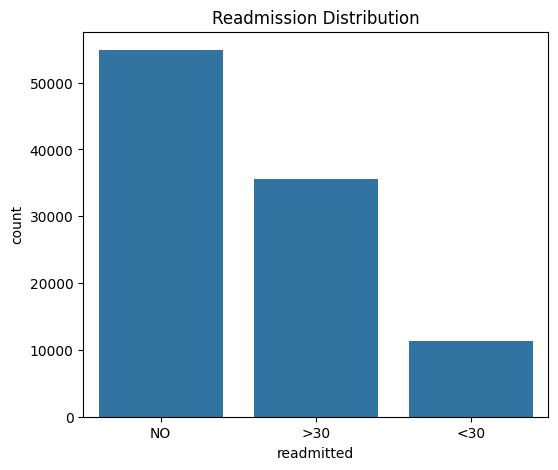

In [40]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="readmitted"
)

plt.title("Readmission Distribution")

plt.show()

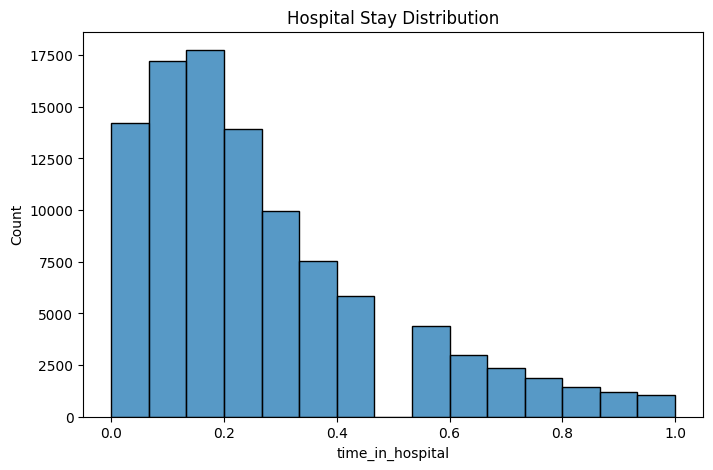

In [41]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["time_in_hospital"],
    bins=15
)

plt.title("Hospital Stay Distribution")

plt.show()

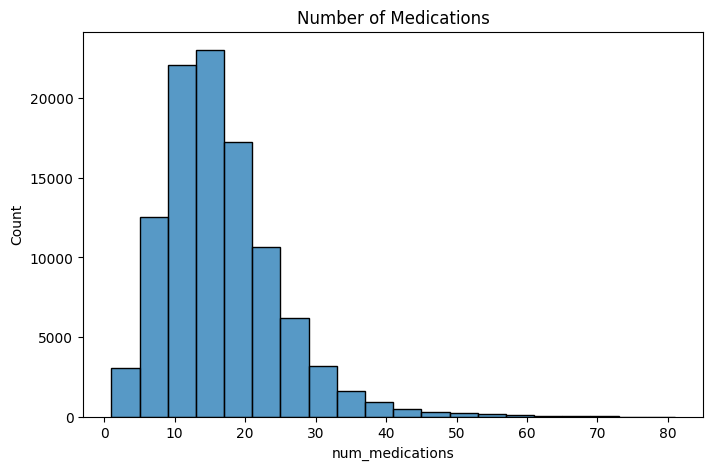

In [42]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["num_medications"],
    bins=20
)

plt.title("Number of Medications")

plt.show()

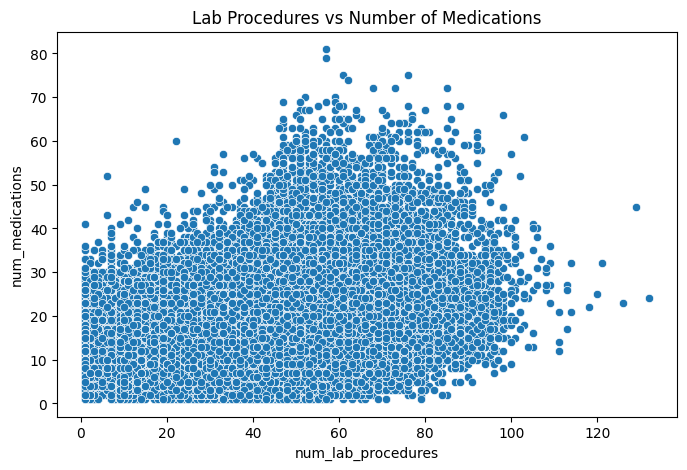

In [43]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="num_lab_procedures",
    y="num_medications"
)

plt.title("Lab Procedures vs Number of Medications")

plt.show()

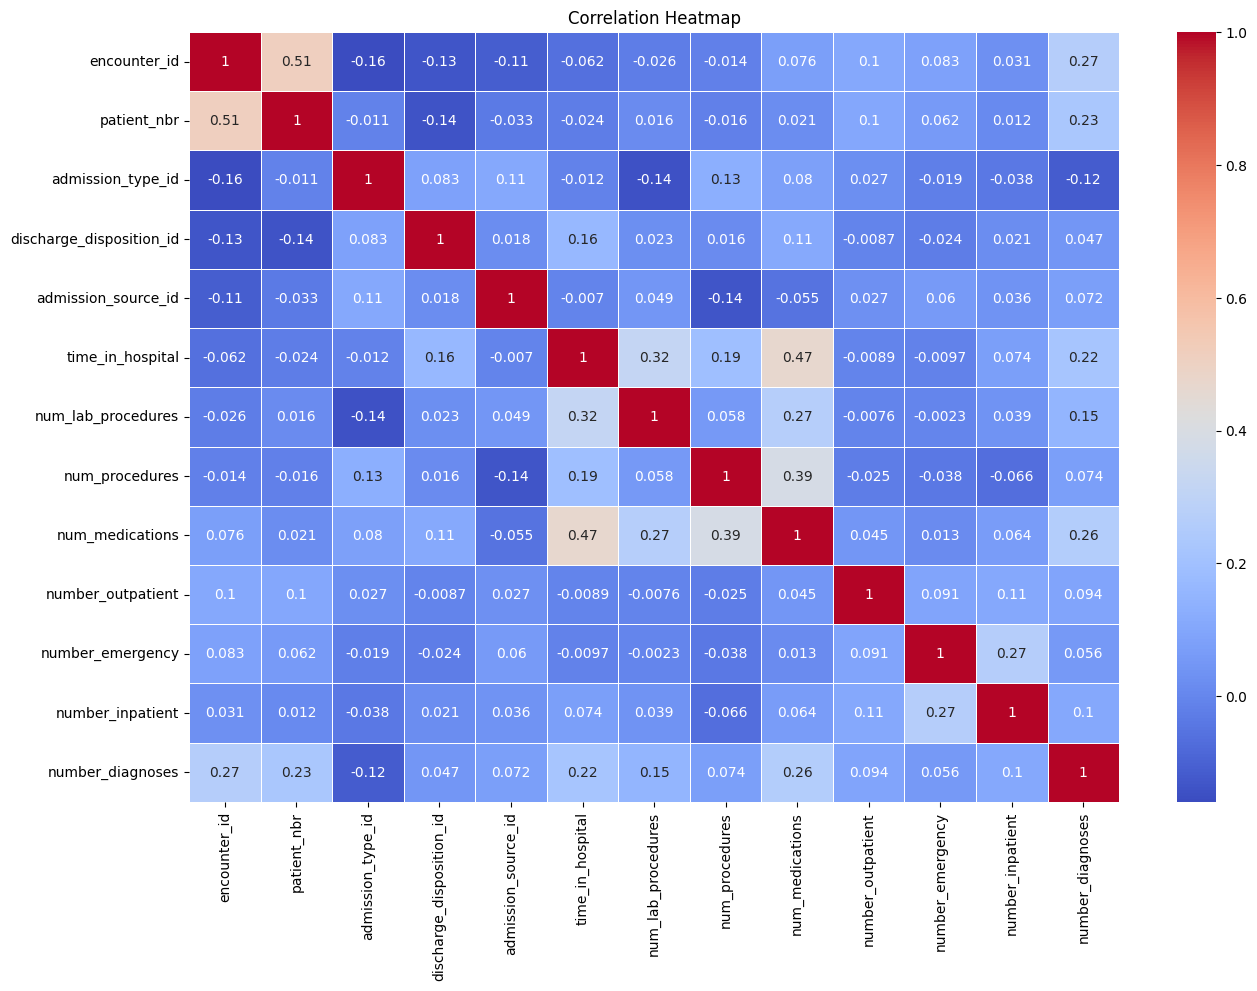

In [44]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(15,10))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

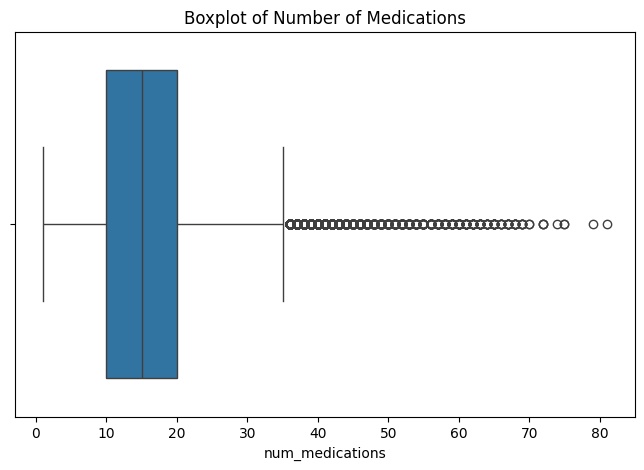

In [45]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["num_medications"]
)

plt.title("Boxplot of Number of Medications")

plt.show()

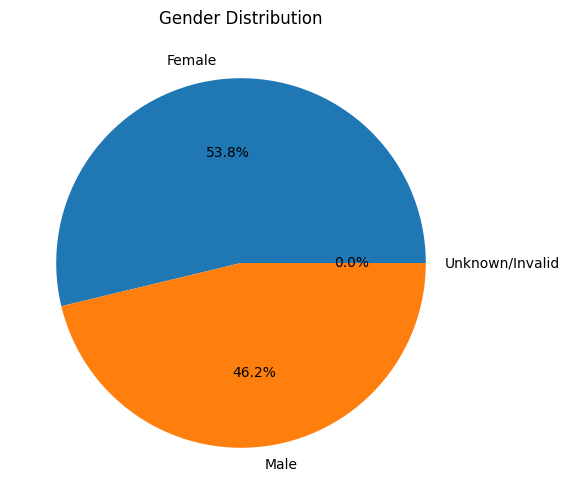

In [46]:
df["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Gender Distribution")

plt.ylabel("")

plt.show()

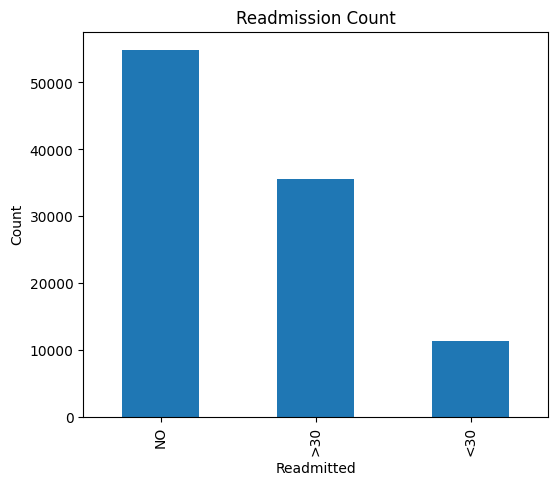

In [47]:
df["readmitted"].value_counts().plot(
    kind="bar",
    figsize=(6,5)
)

plt.title("Readmission Count")

plt.xlabel("Readmitted")

plt.ylabel("Count")

plt.show()

In [48]:
print("Evaluation")
print("-"*40)

print("✔ Dataset successfully loaded.")

print("✔ Missing values handled.")

print("✔ Unnecessary columns removed.")

print("✔ Outliers detected.")

print("✔ Data normalized.")

print("✔ Visualizations generated successfully.")

Evaluation
----------------------------------------
✔ Dataset successfully loaded.
✔ Missing values handled.
✔ Unnecessary columns removed.
✔ Outliers detected.
✔ Data normalized.
✔ Visualizations generated successfully.


In [50]:
df.to_csv("diabetic_data_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
